Missing values in each column:
 school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64
💾 Saved trained_feature_names.pkl
Total features: 41
✅ Train shape: (316, 41), Test shape: (79, 41)
🔍 Model: Linear Regression
📉 Mean Squared Error (MSE): 5.66
📈 Mean Absolute Error (MAE): 1.65
🌟 R² Score: 0.72


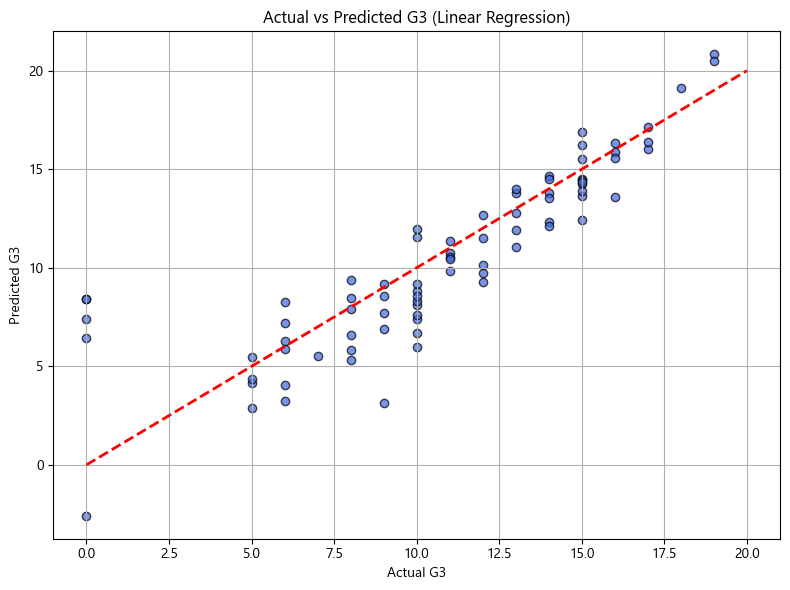


🔍 R² Scores: 
Linear Regression: 0.72
Decision Tree: 0.80
Random Forest: 0.81
Gradient Boosting: 0.80


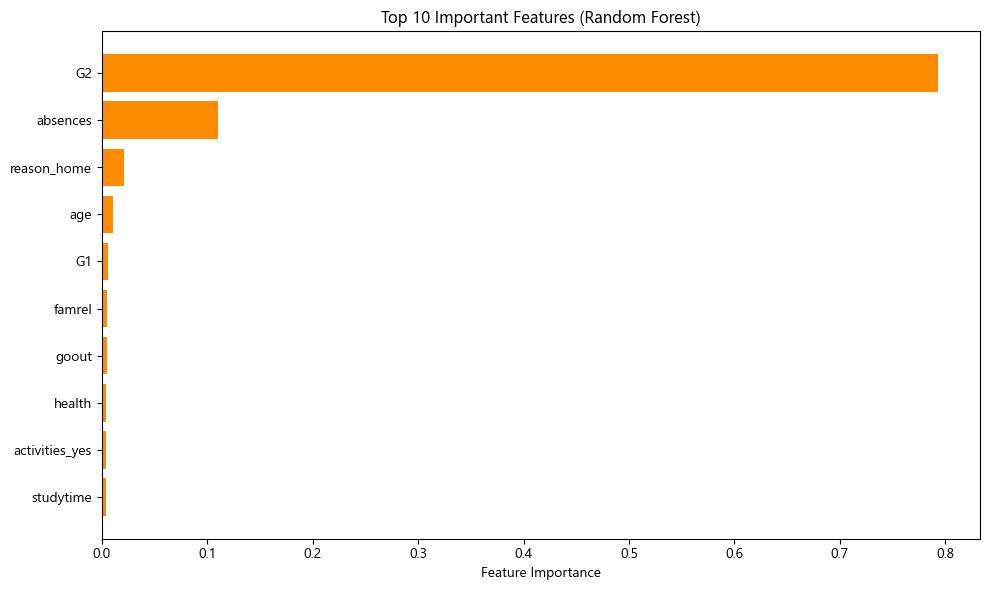

💾 Saved feature importances to 'feature_importances_rf.csv'
📁 Predictions saved to 'predictions_rf.csv'

🔀 Cross-Validation R² Scores: [0.7711521  0.82107737 0.86531169 0.86667028 0.82605946]
🔁 Average R²: 0.83


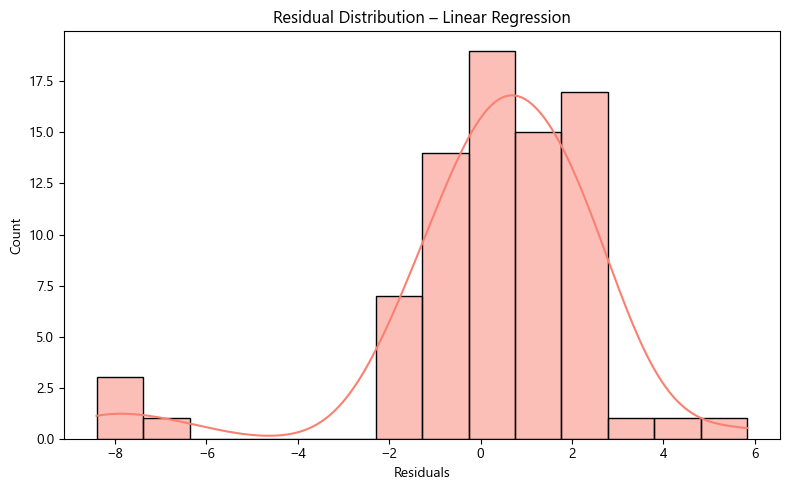


📊 Final Model Comparison:
               Model   MSE   MAE    R2
0      Random Forest  3.80  1.16  0.81
1      Decision Tree  4.20  1.14  0.80
2  Gradient Boosting  4.02  1.16  0.80
3  Linear Regression  5.66  1.65  0.72
📁 Model performance summary saved as 'model_performance_summary.csv'


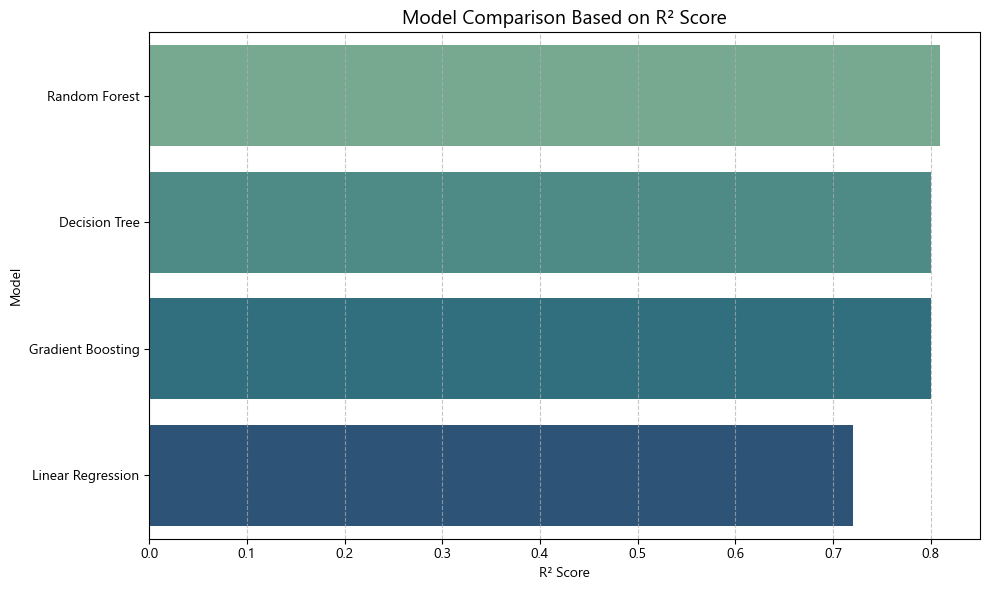

💾 Best model (Random Forest) saved as 'random_forest_model.pkl'


In [2]:
# ----------------------------------------
# 📦 1. Import Libraries & Load Data
# ----------------------------------------
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Segoe UI Emoji'  # Windows
import seaborn as sns
import joblib


# Load the dataset
df = pd.read_csv("student-mat.csv", sep=';')

# ----------------------------------------
# 🧼 2. Data Cleaning & Preprocessing
# ----------------------------------------
print("Missing values in each column:\n", df.isnull().sum())
df.dropna(inplace=True)

"""# ----------------------------------------
# 🔣 3. Feature Encoding
# ----------------------------------------
df_encoded = df.copy()
label_encoder = LabelEncoder()

binary_cols = ['sex', 'schoolsup', 'famsup', 'paid', 'activities',
               'internet', 'romantic', 'nursery', 'higher']
for col in binary_cols:
    if col in df_encoded.columns:
        df_encoded[col] = label_encoder.fit_transform(df_encoded[col])
    else:
        print(f"⚠️ Column '{col}' not found!")

one_hot_cols = ['school', 'address', 'famsize', 'Pstatus', 'Mjob', 
                'Fjob', 'reason', 'guardian']
df_encoded = pd.get_dummies(df_encoded, columns=one_hot_cols, drop_first=True)

if 'name' in df_encoded.columns:
    df_encoded.drop(columns=['name'], inplace=True)

non_numeric_cols = df_encoded.select_dtypes(include=['object']).columns
if len(non_numeric_cols) > 0:
    print(f"🚨 Non-numeric columns remaining: {list(non_numeric_cols)}")
else:
    print("✅ All columns are numeric now!")"""
# ----------------------------------------
# 🔣 3. Feature Encoding (Simplified & Consistent)
# ----------------------------------------
df_encoded = df.copy()

# One-hot encode ALL categorical (object) columns
df_encoded = pd.get_dummies(df_encoded, drop_first=True)

# Ensure target is present
if "G3" not in df_encoded.columns:
    raise ValueError("Target column G3 missing after encoding!")

# Split features and target
X = df_encoded.drop("G3", axis=1)
y = df_encoded["G3"]

# Save feature names for the app
feature_names = X.columns.tolist()
joblib.dump(feature_names, "trained_feature_names.pkl")
print("💾 Saved trained_feature_names.pkl")
print(f"Total features: {len(feature_names)}")

# ----------------------------------------
# 🎯 4. Train-Test Split
# ----------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"✅ Train shape: {X_train.shape}, Test shape: {X_test.shape}")

# ----------------------------------------
# 🧠 5. Model Training – Linear Regression
# ----------------------------------------
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

# ----------------------------------------
# 📊 6. Evaluation – Linear Regression
# ----------------------------------------
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("🔍 Model: Linear Regression")
print(f"📉 Mean Squared Error (MSE): {mse:.2f}")
print(f"📈 Mean Absolute Error (MAE): {mae:.2f}")
print(f"🌟 R² Score: {r2:.2f}")

# ----------------------------------------
# 📈 7. Visualization – Actual vs Predicted
# ----------------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='royalblue', edgecolors='black')
plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Actual vs Predicted G3 (Linear Regression)")
plt.grid(True)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', linewidth=2)
plt.tight_layout()
plt.show()

# ----------------------------------------
# 🤖 8. Train & Evaluate Other Models
# ----------------------------------------
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

print("\n🔍 R² Scores: ")
print(f"Linear Regression: {r2_score(y_test, y_pred):.2f}")
print(f"Decision Tree: {r2_score(y_test, dt_pred):.2f}")
print(f"Random Forest: {r2_score(y_test, rf_pred):.2f}")
print(f"Gradient Boosting: {r2_score(y_test, gb_pred):.2f}")

# ----------------------------------------
# 🔍 9. Feature Importance (Random Forest)
# ----------------------------------------
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-10:]
features = X.columns[indices]
plt.figure(figsize=(10, 6))
plt.barh(features, importances[indices], color='darkorange')
plt.xlabel("Feature Importance")
plt.title("Top 10 Important Features (Random Forest)")
plt.tight_layout()
plt.show()

# Save full feature importance list for the app
feat_imp_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feat_imp_df.to_csv("feature_importances_rf.csv", index=False)
print("💾 Saved feature importances to 'feature_importances_rf.csv'")

# ----------------------------------------
# 📁 10. Export Predictions (Random Forest)
# ----------------------------------------
results_df = pd.DataFrame({"Actual G3": y_test, "Predicted G3": rf_pred})
results_df.to_csv("predictions_rf.csv", index=False)
print("📁 Predictions saved to 'predictions_rf.csv'")

# ----------------------------------------
# 🔀 11. Cross-Validation (Random Forest)
# ----------------------------------------
scores = cross_val_score(rf_model, X, y, cv=5, scoring='r2')
print("\n🔀 Cross-Validation R² Scores:", scores)
print("🔁 Average R²:", np.mean(scores).round(2))

# ----------------------------------------
# 📉 12. Residual Analysis (Linear Regression)
# ----------------------------------------
residuals = y_test - y_pred
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, color="salmon")
plt.title("Residual Distribution – Linear Regression")
plt.xlabel("Residuals")
plt.tight_layout()
plt.show()

# ----------------------------------------
# 📊 13. Model Performance Summary Table
# ----------------------------------------
def evaluate_model(name, y_true, y_pred):
    return {
        "Model": name,
        "MSE": round(mean_squared_error(y_true, y_pred), 2),
        "MAE": round(mean_absolute_error(y_true, y_pred), 2),
        "R2": round(r2_score(y_true, y_pred), 2)
    }

performance_results = [
    evaluate_model("Linear Regression", y_test, y_pred),
    evaluate_model("Decision Tree", y_test, dt_pred),
    evaluate_model("Random Forest", y_test, rf_pred),
    evaluate_model("Gradient Boosting", y_test, gb_pred)
]

performance_df = pd.DataFrame(performance_results)
performance_df = performance_df.sort_values(by="R2", ascending=False).reset_index(drop=True)

print("\n📊 Final Model Comparison:")
print(performance_df)

performance_df.to_csv("model_performance_summary.csv", index=False)
print("📁 Model performance summary saved as 'model_performance_summary.csv'")

# ----------------------------------------
# 📊 14. Visualize Model Comparison
# ----------------------------------------
plt.figure(figsize=(10, 6))
sns.barplot(
    data=performance_df,
    y="Model",
    x="R2",
    hue="Model",
    legend=False,
    palette="crest"
)
plt.title("Model Comparison Based on R² Score", fontsize=14, weight='bold')
plt.xlabel("R² Score")
plt.ylabel("Model")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# ----------------------------------------
# 💾 15. Save Best Model for App (Random Forest)
# ----------------------------------------
joblib.dump(rf_model, "random_forest_model.pkl")
print("💾 Best model (Random Forest) saved as 'random_forest_model.pkl'")
